In [1]:
import re
import pandas as pd
import torch
from transformers import pipeline
from tqdm import tqdm

print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

c:\Users\amirh\Documents\projects\youtube-intelligence-engine\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
Device: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
df = pd.read_csv("../data/processed/comments_preprocessed.csv")

print("Shape:", df.shape)
print("Sample raw text:")
print(df["text"].iloc[0])

Shape: (27330, 10)
Sample raw text:
Wow. It blows my mind the amount of commenters who thought that these videos were made by Ai or a software program. They've always been drawn by hand on an actual whiteboard with dry-erase markers. I would probably use Ai, but the smell of the markers is just too good. JK! There's almost nothing I love more than drawing - It's peaceful, fun and helps you learn a lot about yourself. The irony of Ai is that it's pushing many humans back into real world hobbies again - playing instruments, climbing trees, wood carving, welding, sports, reading physical books, etc. All this slop has made me appreciate the real world so much more.


In [3]:
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"

sentiment_pipeline = pipeline(
    "text-classification",
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    device=0,          # GPU
    batch_size=64,
    truncation=True,
    max_length=512,
    top_k=None         # return all 3 scores not just top 1
)

print("Model loaded.")

c:\Users\amirh\Documents\projects\youtube-intelligence-engine\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\amirh\.cache\huggingface\hub\models--cardiffnlp--twitter-roberta-base-sentiment-latest. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 201/201 [00:00<00:0

Model loaded.


In [4]:
def prepare_for_model(text):
    text = str(text)
    text = re.sub(r'@\w+', '@user', text)       # mask mentions
    text = re.sub(r'http\S+|www\S+', 'http', text)  # mask URLs
    return text

df["text_for_model"] = df["text"].apply(prepare_for_model)

print("Done.")
print("Sample:", df["text_for_model"].iloc[0])

Done.
Sample: Wow. It blows my mind the amount of commenters who thought that these videos were made by Ai or a software program. They've always been drawn by hand on an actual whiteboard with dry-erase markers. I would probably use Ai, but the smell of the markers is just too good. JK! There's almost nothing I love more than drawing - It's peaceful, fun and helps you learn a lot about yourself. The irony of Ai is that it's pushing many humans back into real world hobbies again - playing instruments, climbing trees, wood carving, welding, sports, reading physical books, etc. All this slop has made me appreciate the real world so much more.


In [5]:
texts = df["text_for_model"].tolist()
results = []

for out in tqdm(sentiment_pipeline(texts), total=len(texts), desc="Sentiment"):
    scores = {item["label"].lower(): item["score"] for item in out}
    label = max(scores, key=scores.get)
    results.append({
        "sentiment":       label,
        "score_negative":  round(scores.get("negative", 0), 4),
        "score_neutral":   round(scores.get("neutral", 0), 4),
        "score_positive":  round(scores.get("positive", 0), 4),
        "confidence":      round(scores[label], 4)
    })

sentiment_df = pd.DataFrame(results)
df = pd.concat([df, sentiment_df], axis=1)

print("Done.")
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())
print("\nDistribution %:")
print(df["sentiment"].value_counts(normalize=True).round(3) * 100)

Sentiment: 100%|██████████| 27330/27330 [00:00<00:00, 117687.86it/s]


Done.

Sentiment distribution:
sentiment
negative    13713
neutral      8517
positive     5100
Name: count, dtype: int64

Distribution %:
sentiment
negative    50.2
neutral     31.2
positive    18.7
Name: proportion, dtype: float64


In [6]:
sentiment_by_video = df.groupby("video_name")["sentiment"].value_counts(normalize=True).round(3) * 100
print(sentiment_by_video)

video_name                  sentiment
ai_fails_96_percent         negative     54.7
                            neutral      29.5
                            positive     15.8
ai_might_not_replace_jobs   negative     54.4
                            neutral      32.6
                            positive     13.0
ai_slop_renaissance         positive     47.3
                            negative     30.5
                            neutral      22.3
ai_white_collar_12months    negative     41.8
                            neutral      34.8
                            positive     23.4
capitalism_no_workers       negative     56.2
                            neutral      36.4
                            positive      7.4
replacing_developers_wrong  negative     60.1
                            neutral      28.2
                            positive     11.7
replacing_humans_wrong      negative     48.8
                            neutral      31.3
                            positive     1

In [7]:
df.to_csv("../data/processed/comments_sentiment.csv", index=False, encoding="utf-8-sig")
print(f"Saved {len(df)} rows")
print("Columns:", df.columns.tolist())

Saved 27330 rows
Columns: ['video_id', 'video_name', 'comment_id', 'author', 'text', 'likes', 'published_at', 'reply_count', 'text_clean', 'text_lemma', 'text_for_model', 'sentiment', 'score_negative', 'score_neutral', 'score_positive', 'confidence']


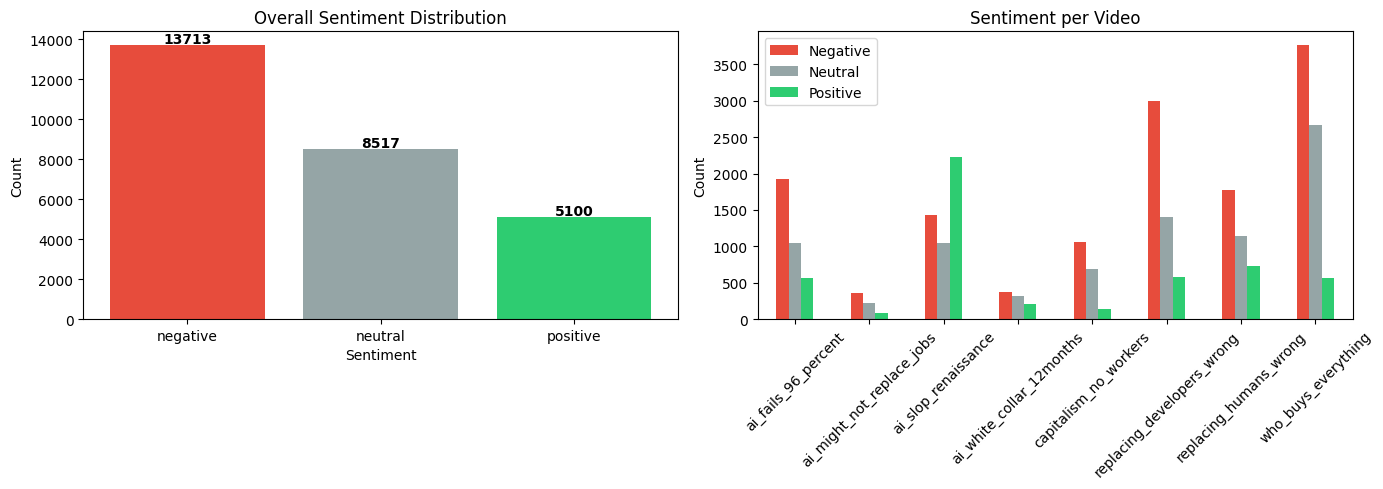

Chart saved.


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sentiment_counts = df["sentiment"].value_counts()
colors = ["#e74c3c", "#95a5a6", "#2ecc71"]
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors)
axes[0].set_title("Overall Sentiment Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 100, str(v), ha="center", fontweight="bold")

video_sentiment = df.groupby(["video_name", "sentiment"]).size().unstack(fill_value=0)
video_sentiment.plot(kind="bar", ax=axes[1], color=colors, rot=45)
axes[1].set_title("Sentiment per Video")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].legend(["Negative", "Neutral", "Positive"])

plt.tight_layout()
plt.savefig("../data/processed/sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")